# W9 — Polytomy Tanglegram

Through W8 we plotted the "true tree" and the "IQ-TREE-inferred tree" separately and compared them by eye. This week puts them **side by side in one figure, with lines connecting matching leaves** — a tanglegram — for a much more direct comparison.

Standard tanglegram tools (e.g. scipy hierarchical clustering) only handle binary trees, but our transmission tree naturally has **polytomies** (one individual can infect several others at once). So we use a self-contained implementation that supports polytomies directly (`cophylogeny/polytomy_tanglegram.py`).

In [3]:
import sys
import os
sys.path.append("../intervention_search")

import covasim as cv

from simulation.runner import run_evo_simulation

## 1) Simulation setup

Nearly the same setup as W7/W8, but two values are bumped up: `mol_clock_rate` by 100x (0.000001 -> 0.0001) and `p_test` from 0.2 to 0.3. This produces more mutation and sequencing events, so there are enough leaves to make a meaningful tanglegram.

In [4]:
sim_pars = dict(
    pop_size=3000,
    pop_type='hybrid',
    pop_infected=5,
    n_days=60,
    rand_seed=1,
    beta=0.1, 
    verbose=0,    
)

evo_pars = dict(
  enable=True,
  reference="/home/jhkim/covasim_project/covasim4wastewater/docs/tutorials/sars-2-data/NC_045512_Hu-1.fasta",
  mol_clock_rate=0.0001,
  sub_model="JC",
  fitness_data_path="/home/jhkim/covasim_project/covasim4wastewater/data/nt_fitness.csv",
  store_infection_log=True,
) 

policy = dict(
    p_test=0.3,
    p_seq=0.5,
    detection_threshold=3,
    delay_pmf=[0.05, 0.15, 0.30, 0.25, 0.15, 0.07, 0.03],
    quiet_period=0,
)

## 2) Run the simulation

After running, print the total infection count (`cum`) as a quick sanity check that this run produced enough sequenced haplotypes (i.e., leaves) for the tanglegram.

In [5]:
sim, obs, interv, _, results = run_evo_simulation(sim_pars, evo_pars, policy)

In [6]:
cum = int(sim.results['new_infections'].values.sum())

print(cum)

225


## 3-5) Event tree -> haplotype tree -> pruning

Repeats the same three steps as W8 (build the event-based tree, collapse it into a haplotype tree, then prune down to the sequenced lineage). See W8 for details.

In [7]:
from analysis.mutation_tree import build_mutation_tree, build_infection_seq_tree, mutation_tree_to_newick, extract_sequenced_subtree, export_fasta_from_G, infer_tree_jc69, add_internal_leaves, set_all_branch_lengths_to_one
from plotting.plot_mutation_tree import plot_erase_mutation_tree, plot_phylo_tree

In [8]:
FIG_DIR = "../intervention_search/results/figures"

Policy B mutation tree: nodes=231, edges=230


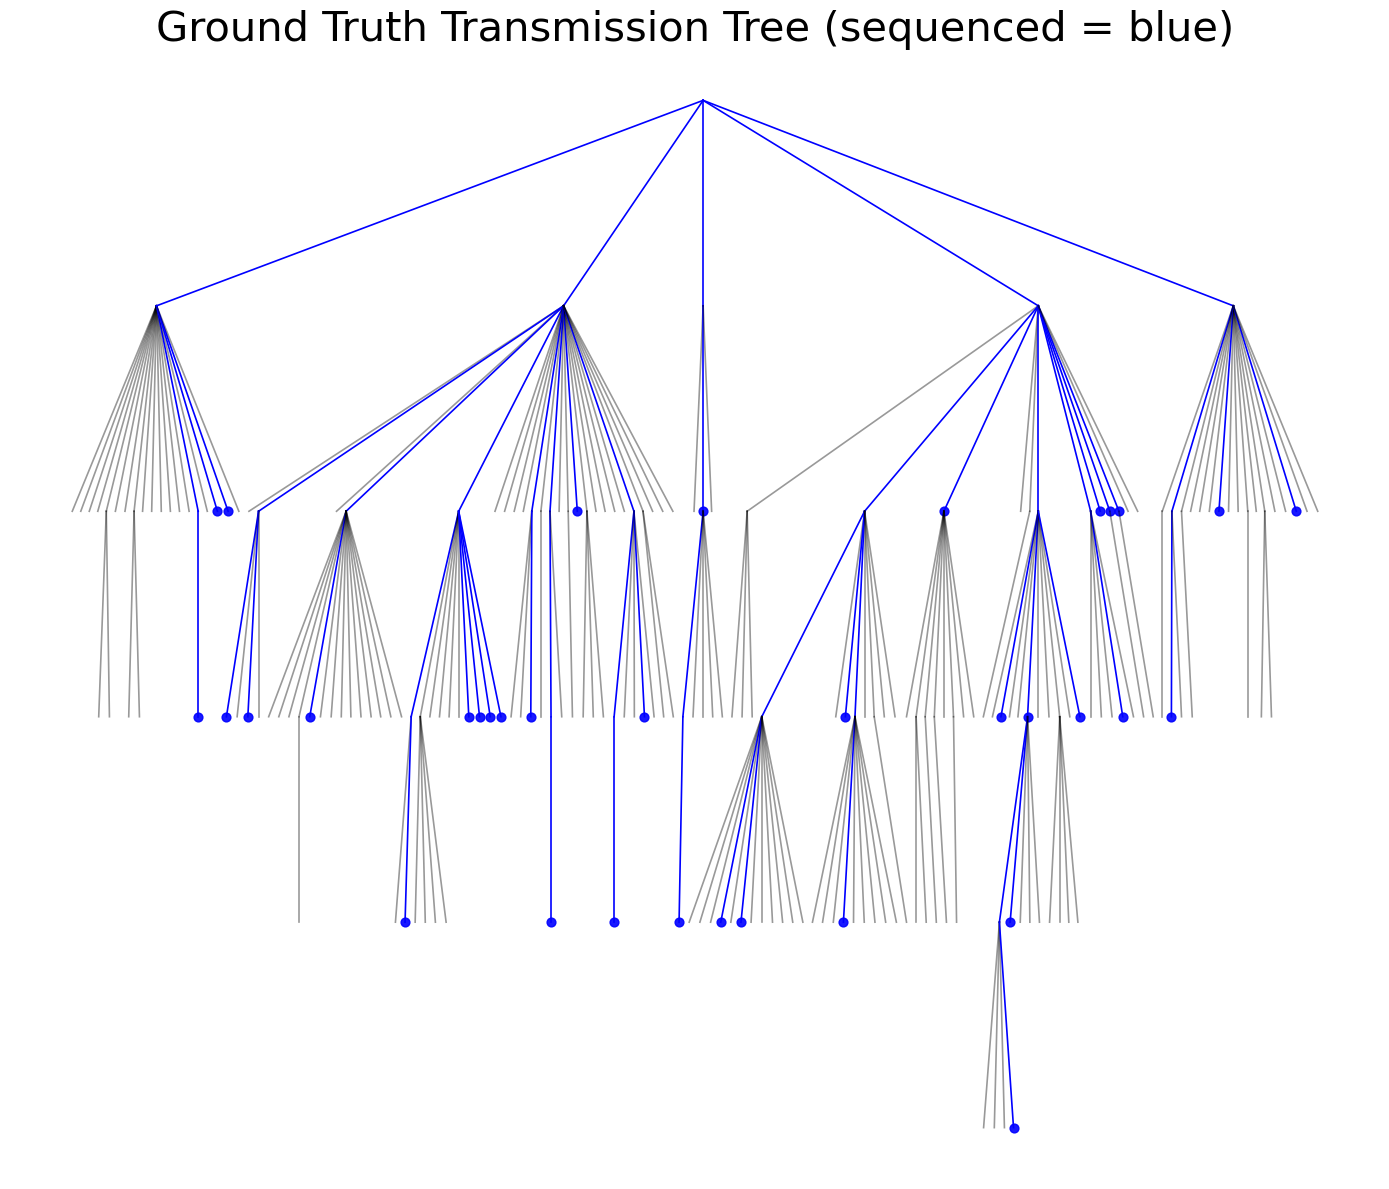

Policy B mutation tree: nodes=226, edges=225


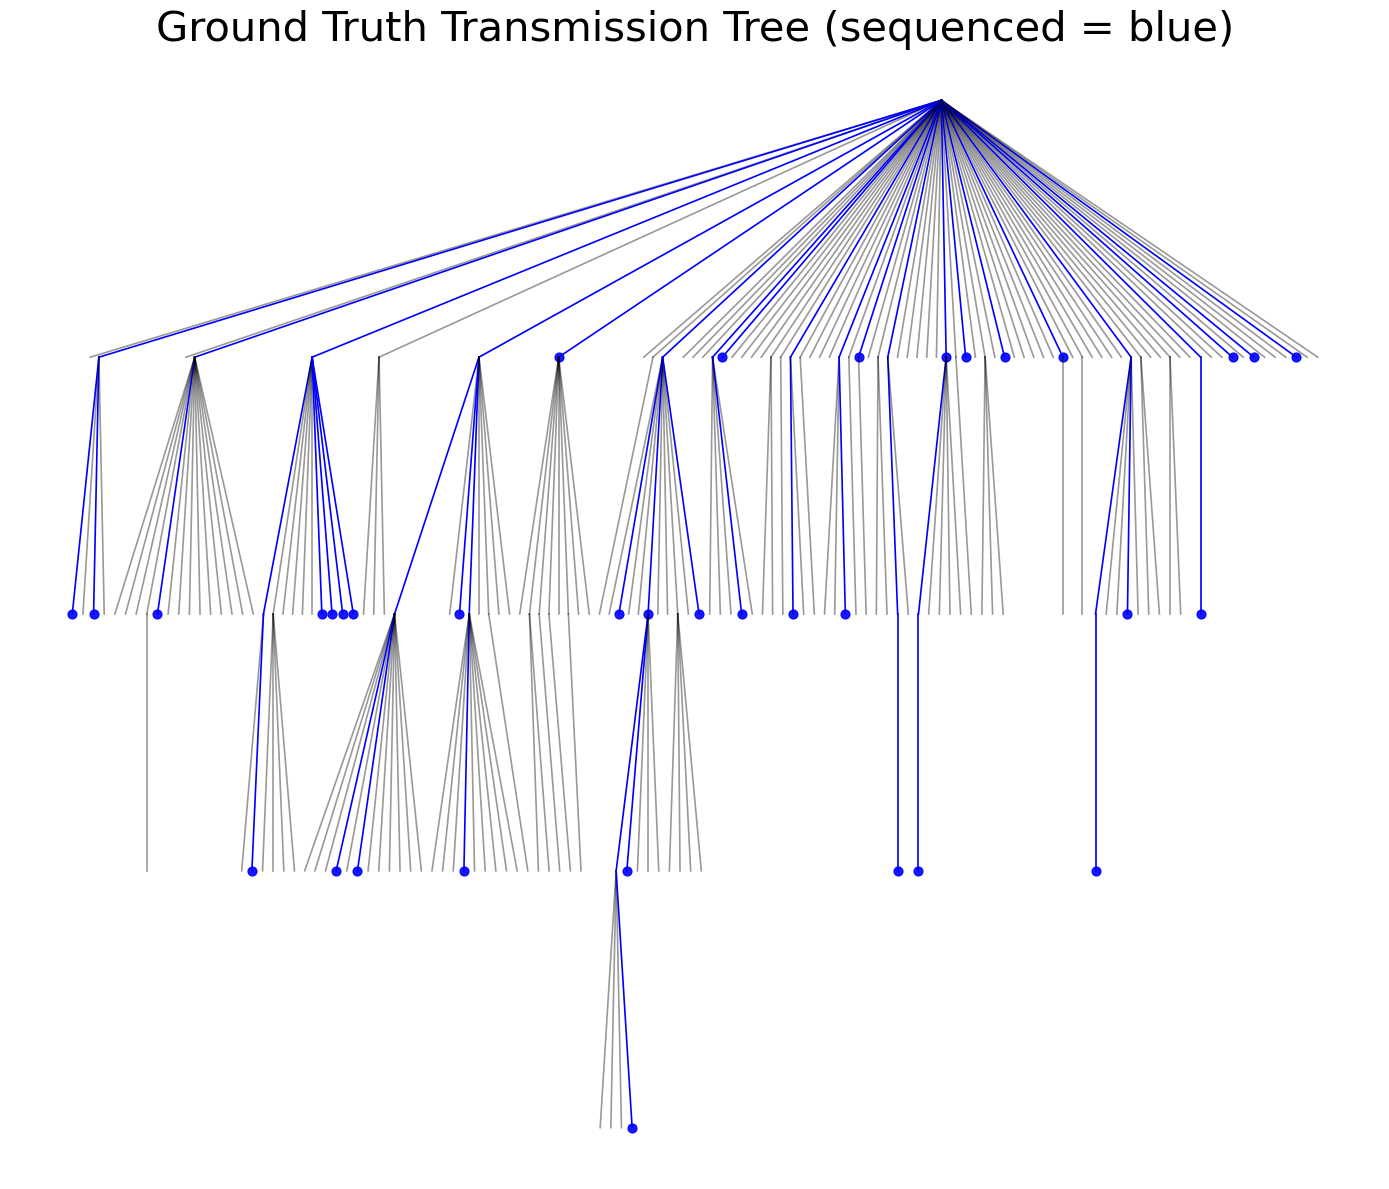

Policy B mutation tree: nodes=54, edges=53


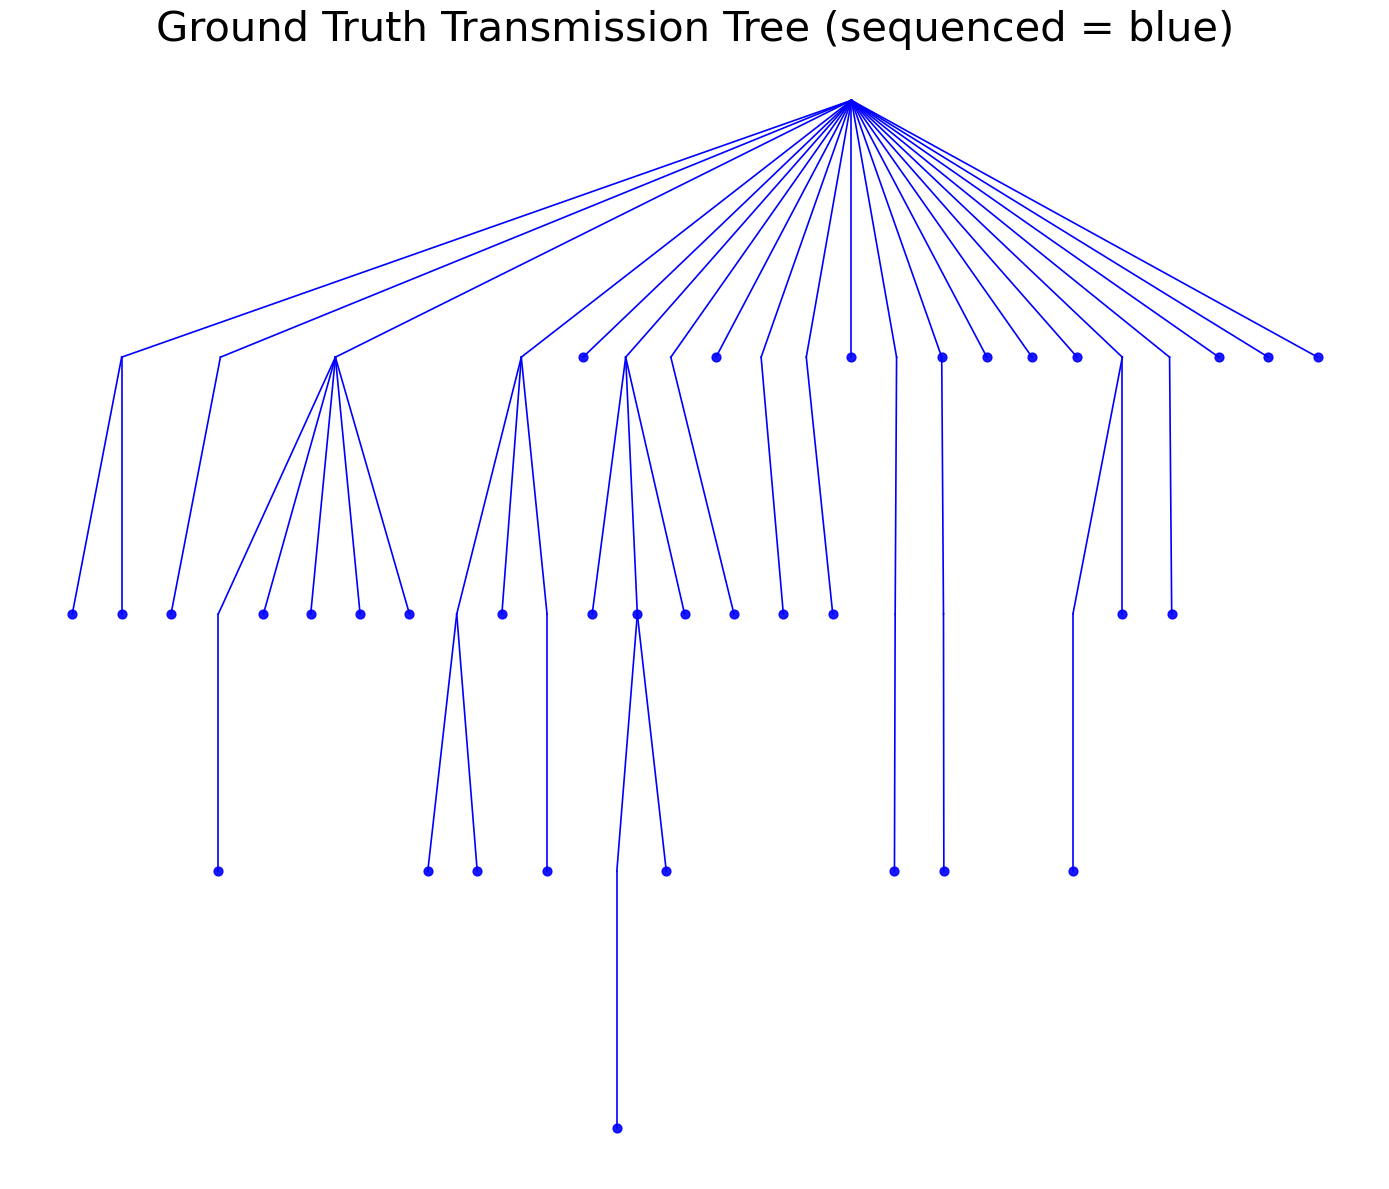

In [9]:
sequenced_agents = set()
for day_list in obs.daily_sequenced_agents:
    sequenced_agents.update(day_list)

G = build_mutation_tree(sim, daily_sequenced_agents=obs.daily_sequenced_agents)
print(f"Policy B mutation tree: nodes={len(G.nodes)}, edges={len(G.edges)}")

plot_erase_mutation_tree(
    G,
    savepath=os.path.join(FIG_DIR, "mutation_tree_policy_seq.png"),
    show=True,
    detection_day=None,
    erase=False,          # True = edge -> delete, False = edge -> transparent
    sequenced_only=False,
    collapse=False,
)

G_infect, mutation_nodes, node_events = build_infection_seq_tree(sim, daily_sequenced_agents=obs.daily_sequenced_agents)
print(f"Policy B mutation tree: nodes={len(G_infect.nodes)}, edges={len(G_infect.edges)}")

plot_erase_mutation_tree(
    G_infect,
    savepath=os.path.join(FIG_DIR, "mutation_tree_policy_seq.png"),
    show=True,
    detection_day=None,
    erase=False,          # True = edge -> delete, False = edge -> transparent
    sequenced_only=False,
    collapse=False,
)

G_prune = extract_sequenced_subtree(G_infect)
print(f"Policy B mutation tree: nodes={len(G_prune.nodes)}, edges={len(G_prune.edges)}")

plot_erase_mutation_tree(
    G_prune,
    savepath=os.path.join(FIG_DIR, "mutation_tree_prune_seq.png"),
    show=True,
    detection_day=None,
    erase=False,          # True = edge -> delete, False = edge -> transparent
    sequenced_only=False,
    collapse=False,
)

## 6) Duplicate internal nodes as leaves — `add_internal_leaves`

Up to now, the haplotype tree's ancestral states (internal nodes) aren't visible on their own — they only exist as the branch leading to their descendants. A tanglegram connects leaves to leaves, so **ancestral haplotypes need to become standalone leaves too**, or there's no way to line them up between the two trees.

`add_internal_leaves()` attaches a pendant leaf named `"{original_name}_internal"` to every node that has children. From here on (`G_prune_leaf`), former internal nodes are treated as leaves as well.

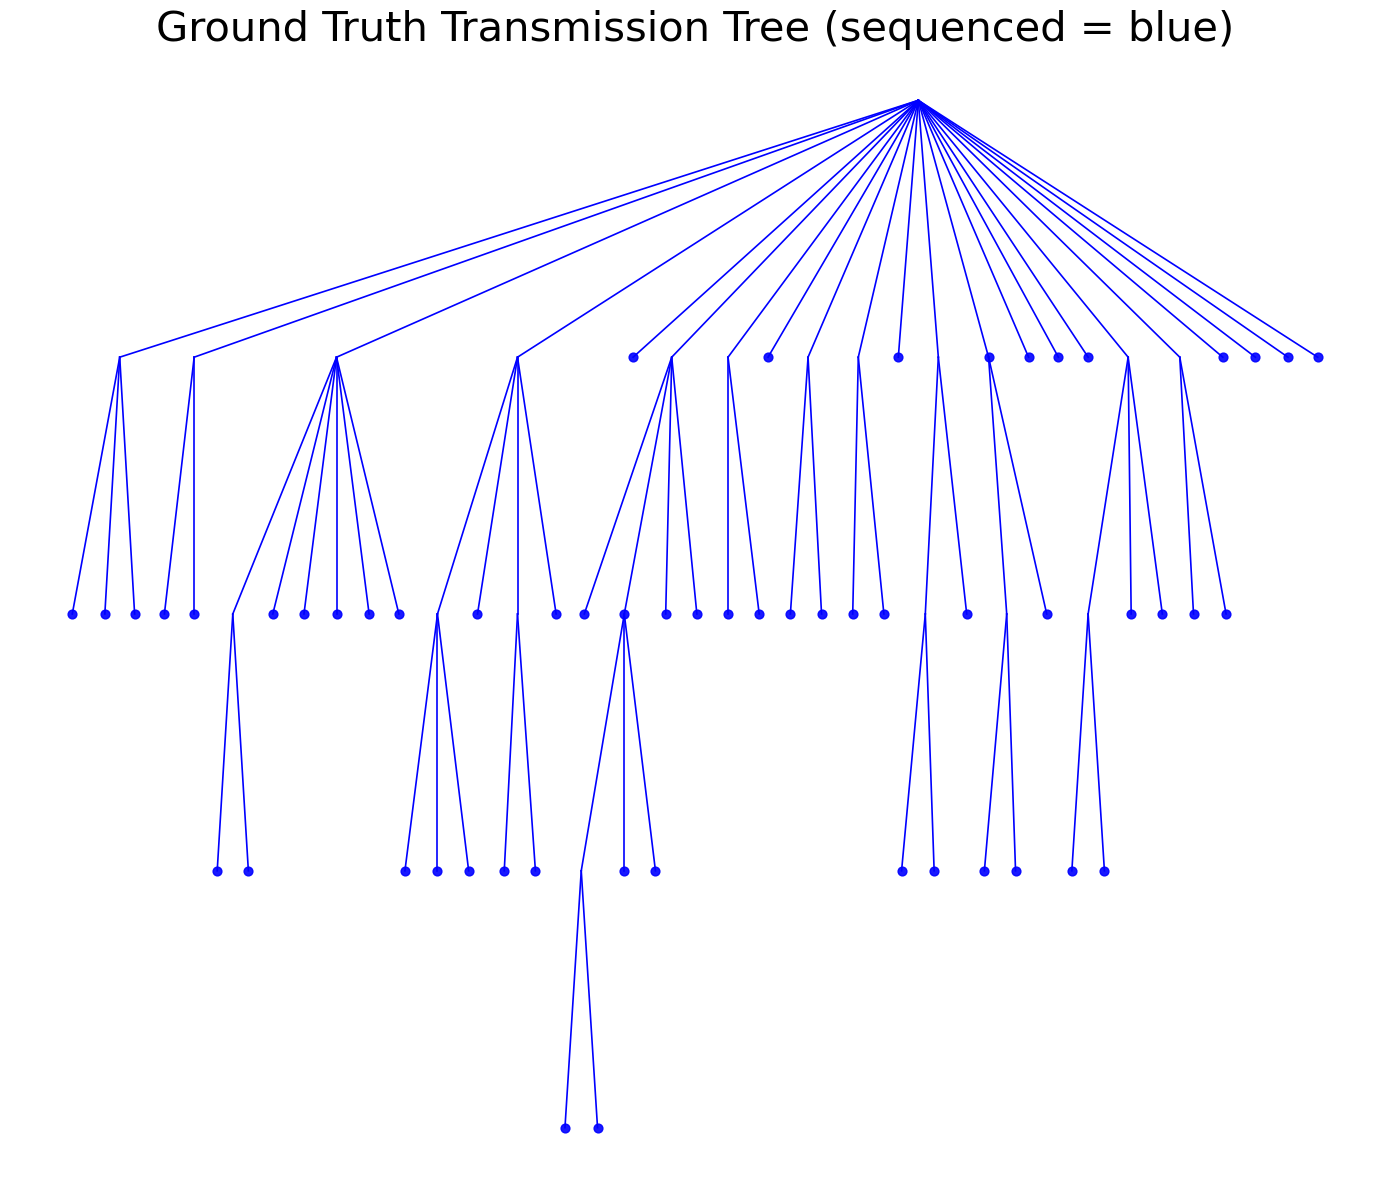

In [10]:
G_prune_leaf = add_internal_leaves(G_prune)
plot_erase_mutation_tree(
    G_prune_leaf,
    savepath=os.path.join(FIG_DIR, "mutation_tree_prune_seq.png"),
    show=True,
    detection_day=None,
    erase=False,          # True = edge -> delete, False = edge -> transparent
    sequenced_only=False,
    collapse=False,
)

## 7) Visualize the "true" subsampled transmission tree

Convert the leaf-augmented tree to Newick and plot it. This is the **ground-truth tree** that will form one side of the tanglegram. The resulting Newick string (`newick_str`) gets reused later when we actually draw the tanglegram, so keep the variable name around.

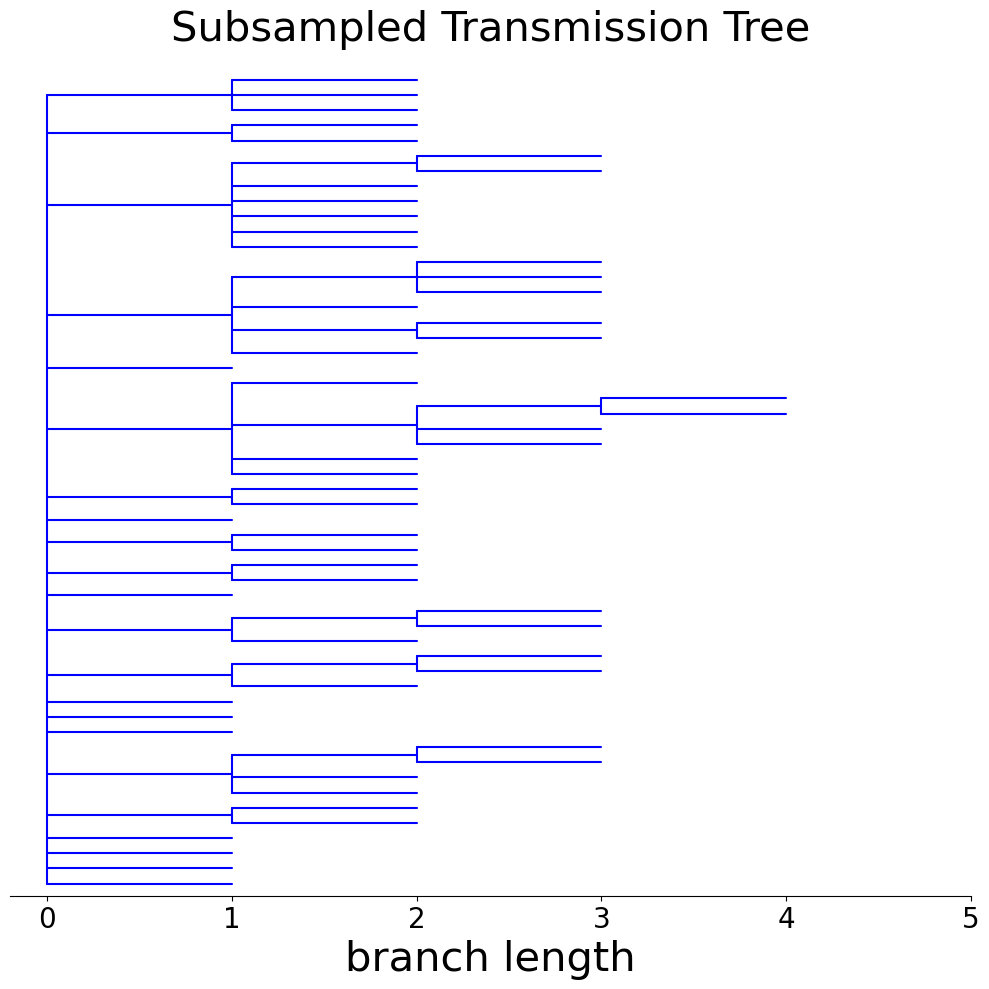

In [11]:
newick_str = mutation_tree_to_newick(G_prune_leaf)

from io import StringIO
from Bio import Phylo
import matplotlib.pyplot as plt

tree = Phylo.read(StringIO(newick_str), "newick")

fig = plt.figure(figsize=(10, 10))  
ax = fig.add_subplot(1, 1, 1)

Phylo.draw(
    tree, 
    do_show=False, 
    axes=ax,
    label_func=lambda x: None
)    

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_xlabel(ax.get_xlabel(), fontsize=30)
ax.tick_params(axis='x', labelsize=20)
ax.get_yaxis().set_visible(False)

for coll in ax.collections:
    coll.set_color("blue")
    

plt.title("Subsampled Transmission Tree", fontsize=30, pad=20)
plt.tight_layout()

plt.show()

## 8) The IQ-TREE-inferred tree (the other side)

This time, export FASTA from `G_prune` (the plain haplotype tree, before internal-leaf duplication) and infer a tree with IQ-TREE. IQ-TREE's branch lengths reflect actual evolutionary distance, while the "true tree" from 7) has every branch length fixed at 1 — **the two aren't on a comparable scale**. `set_all_branch_lengths_to_one()` normalizes the IQ-TREE tree's branch lengths to 1 too, so only topology (who groups with whom) is being compared.

IQ-TREE version 3.1.2 for Linux x86 64-bit built May 17 2026
Developed by Bui Quang Minh, Thomas Wong, Nhan Ly-Trong, Huaiyan Ren
Contributed by Lam-Tung Nguyen, Dominik Schrempf, Chris Bielow,
Olga Chernomor, Michael Woodhams, Diep Thi Hoang, Heiko Schmidt

Host:    localhost (AVX2, FMA3, 7 GB RAM)
Command: iqtree -s polytomy_test.fasta -m JC69 -czb
Seed:    363117 (Using SPRNG - Scalable Parallel Random Number Generator)
Time:    Thu Sep  3 19:41:21 2026
Kernel:  AVX+FMA - 1 threads (18 CPU cores detected)

HINT: Use -nt option to specify number of threads because your CPU has 18 cores!
HINT: -nt AUTO will automatically determine the best number of threads to use.

Reading alignment file polytomy_test.fasta ... Fasta format detected
Reading fasta file: done in 0.0138052 secs using 93.83% CPU
Alignment most likely contains DNA/RNA sequences
Constructing alignment: done in 0.0178881 secs using 99.98% CPU
Alignment has 54 sequences with 29903 columns, 474 distinct patterns
273 parsimony

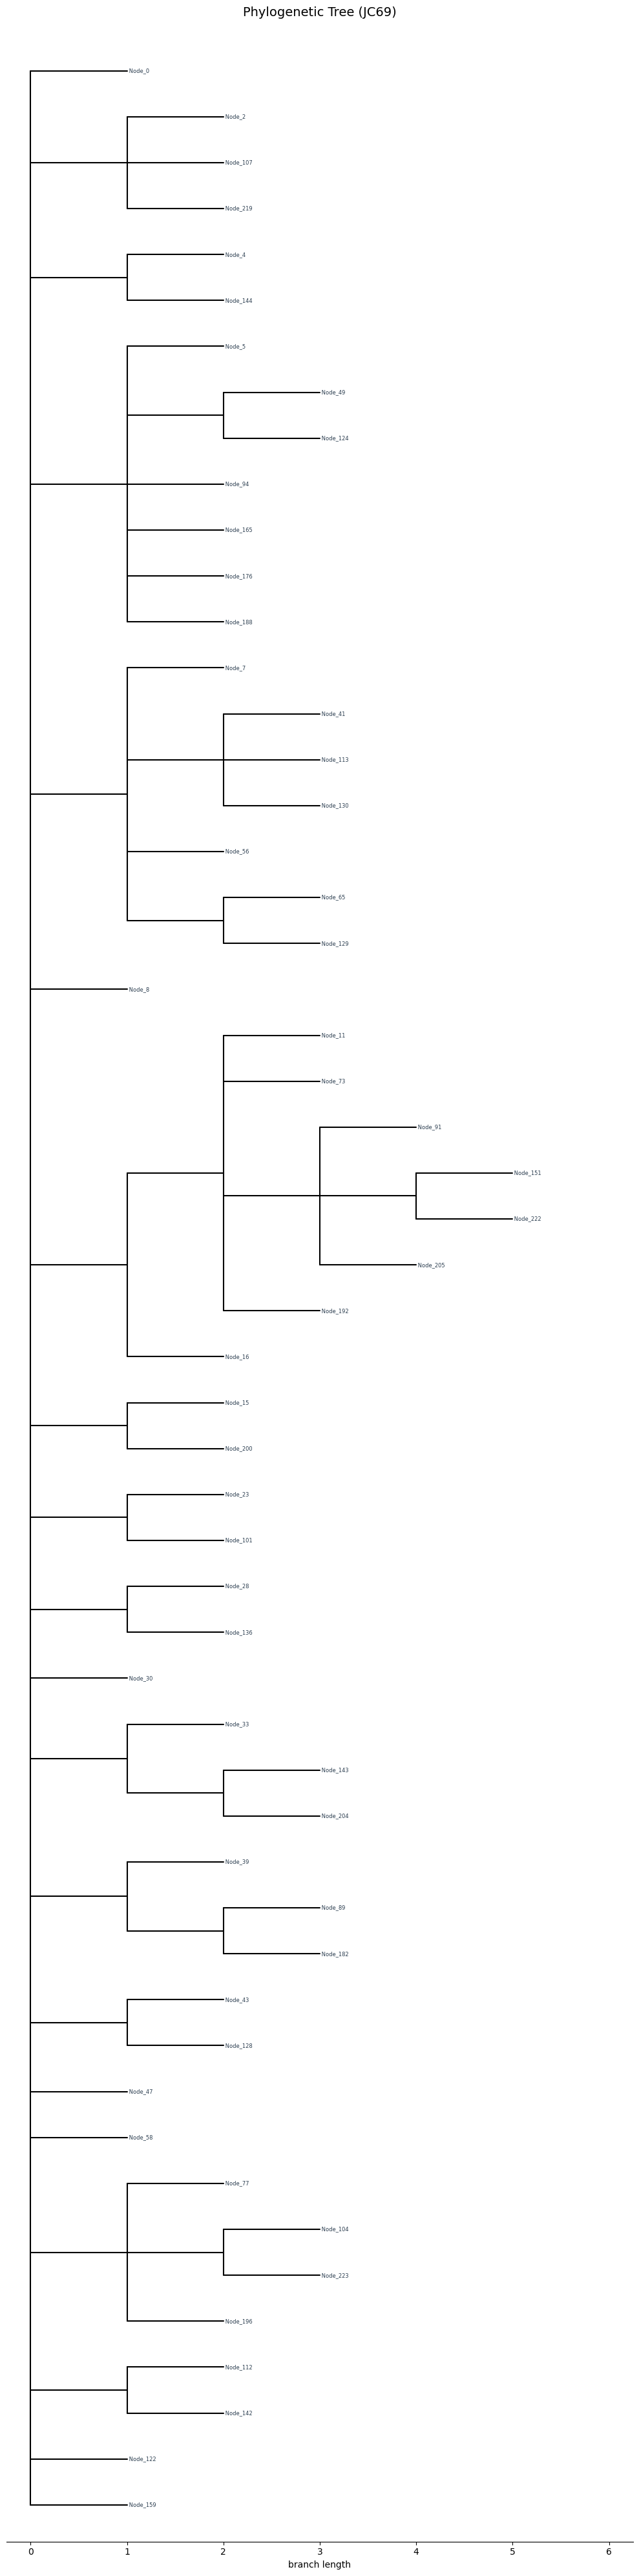

In [12]:
fasta_path = "polytomy_test.fasta"
export_fasta_from_G(G_prune, sim, fasta_path)

newick_path = infer_tree_jc69(fasta_path)

newick_bl1_path = set_all_branch_lengths_to_one(newick_path)

plot_phylo_tree(newick_bl1_path, savepath=None)

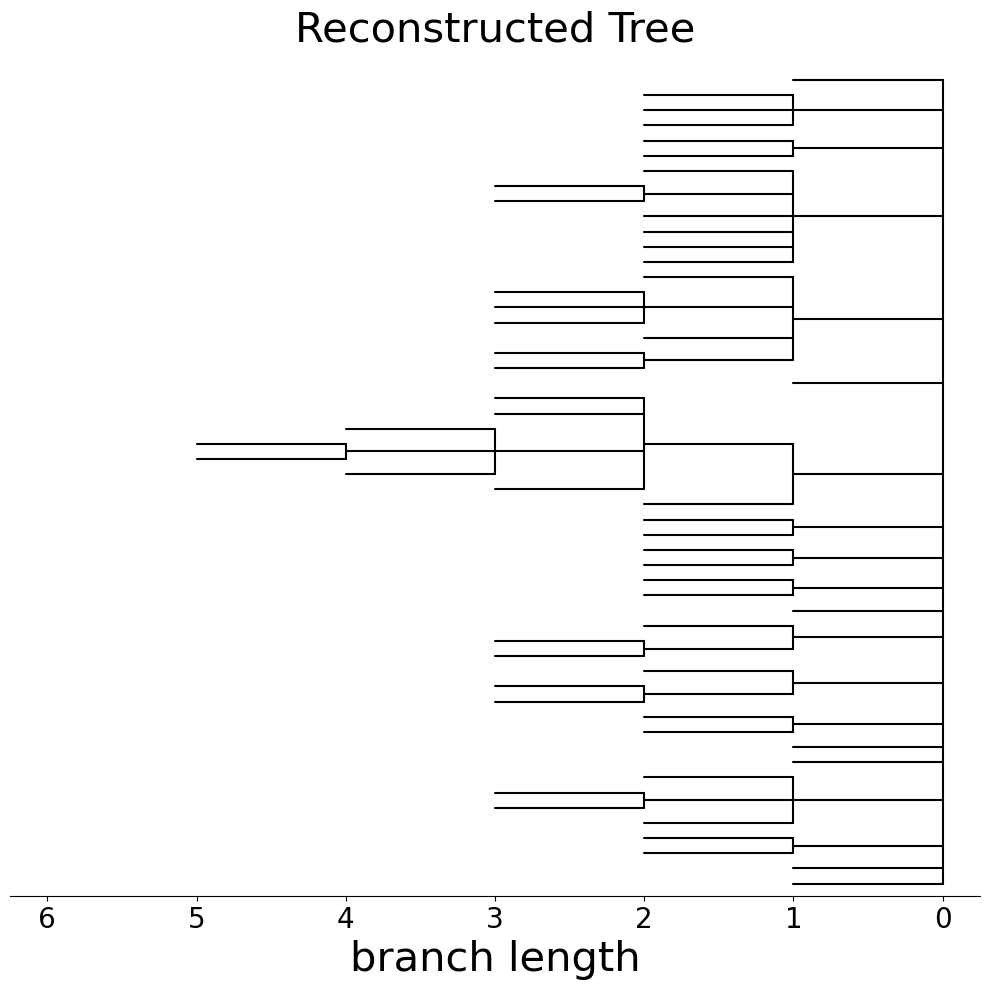

In [13]:
tree = Phylo.read(newick_bl1_path, "newick")

fig = plt.figure(figsize=(10, 10))  
ax = fig.add_subplot(1, 1, 1)

Phylo.draw(
    tree, 
    do_show=False, 
    axes=ax,
    label_func=lambda x: None
)
ax.invert_xaxis()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

ax.set_xlabel(ax.get_xlabel(), fontsize=30)
ax.tick_params(axis='x', labelsize=20)
ax.get_yaxis().set_visible(False)

plt.title("Reconstructed Tree", fontsize=30, pad=20)
plt.tight_layout()
plt.show()


> **Delete** the `cophylogeny.tanglegram.plot_tanglegram` call below. That module re-imports itself and calls functions that were never defined in it, so importing it raises an error on the spot. The version actually used is the `polytomy_tanglegram` call in the next cell.

INFO  : Finished optimising at entanglement 0.008 (tanglegram.tangle)
INFO  : Finished optimising at entanglement 0.008 (tanglegram.tangle)
INFO  : Done. Use matplotlib.pyplot.show() to show plot. (tanglegram.tangle)


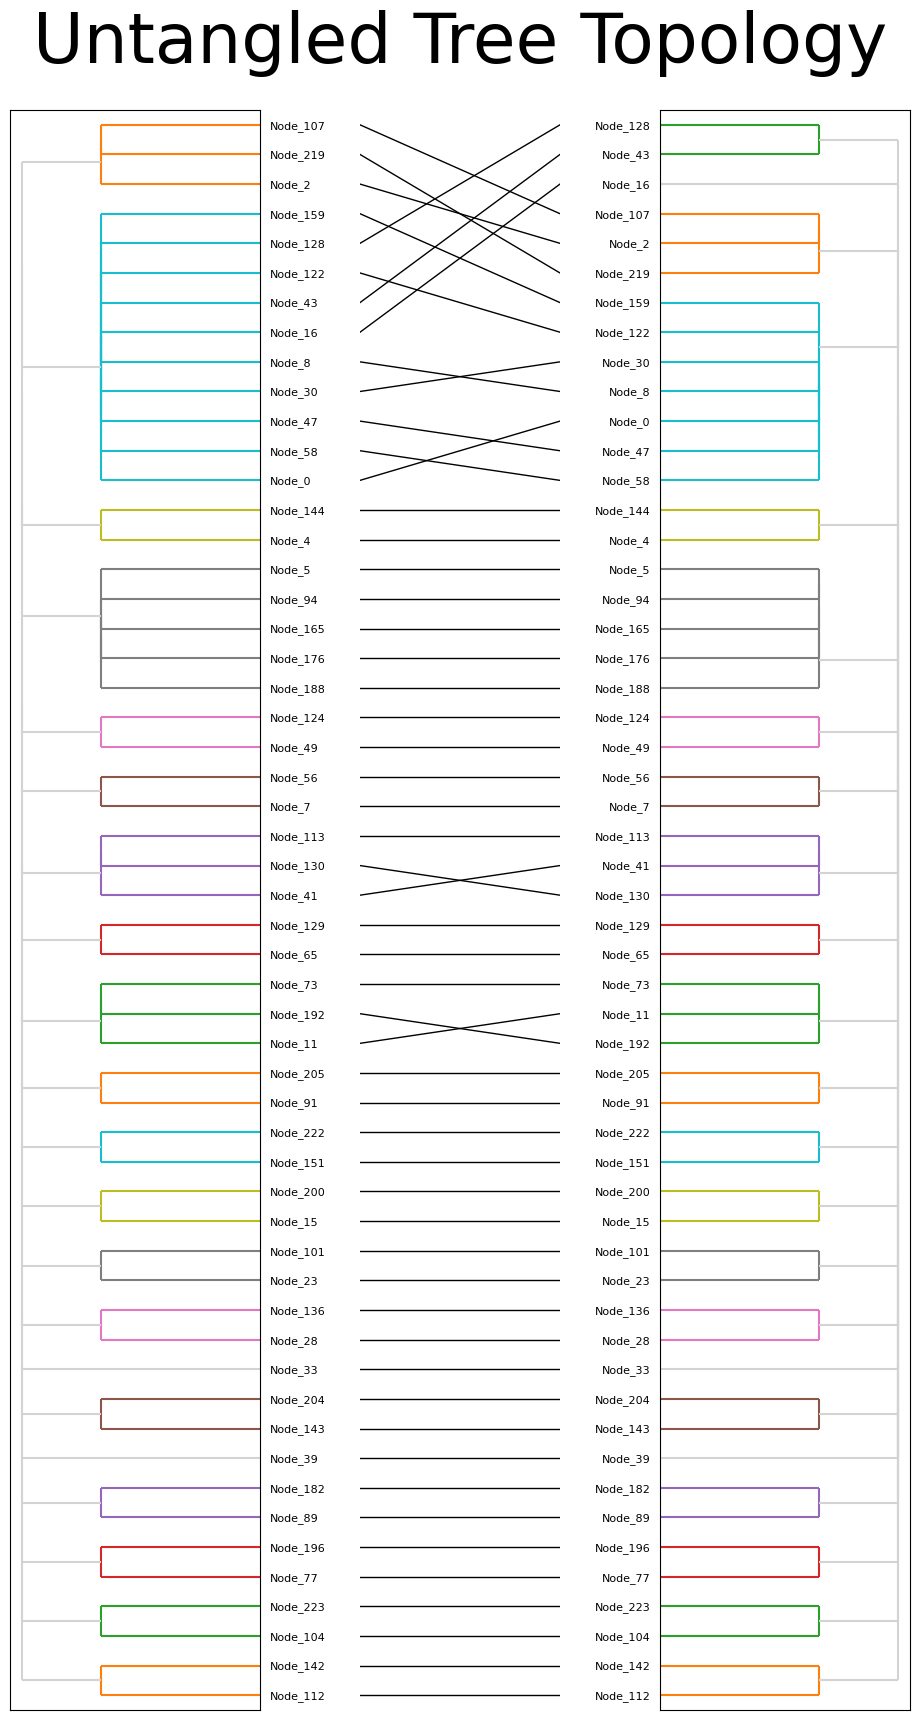

Entanglement: 0.0076128345344189784
Crossings: 20
Alignment quality: Alignment quality (54 leafs, 54 edges)
  entanglement           0.0076   (random layout: 0.5520 +/- 0.1161, z = -4.7)
  crossings                  20
  better than random       99%
  displacement       median 0, max 5 slots; 89% of edges within 2
  verdict            re-optimising reached 0.0071; try more restarts


In [12]:
from cophylogeny.tanglegram import plot_tanglegram

plot_tanglegram(newick_str, newick_bl1_path)

## 9) Tanglegram — the final comparison

`run_polytomy_tanglegram()` parses both Newick trees (the ground-truth tree from 7, the IQ-TREE inference from 8), matches leaves by name, optimizes the child order at every polytomy node to minimize crossing lines, and draws them side by side.

If the connecting lines are nearly parallel, IQ-TREE recovered the true transmission structure well; if they're still tangled after crossing minimization, some transmission paths simply aren't distinguishable from sequence similarity alone — that's the conclusion this whole pipeline has been building toward.

crossings before: 107
crossings after:  0


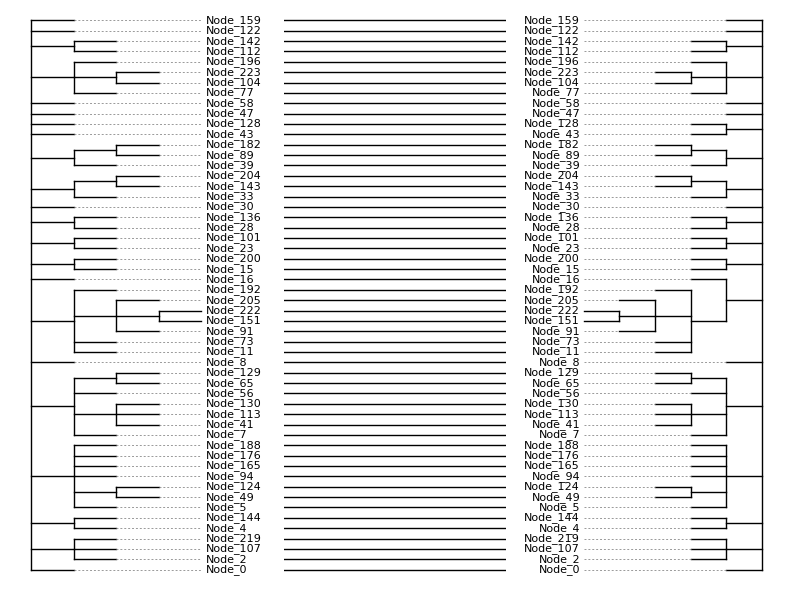

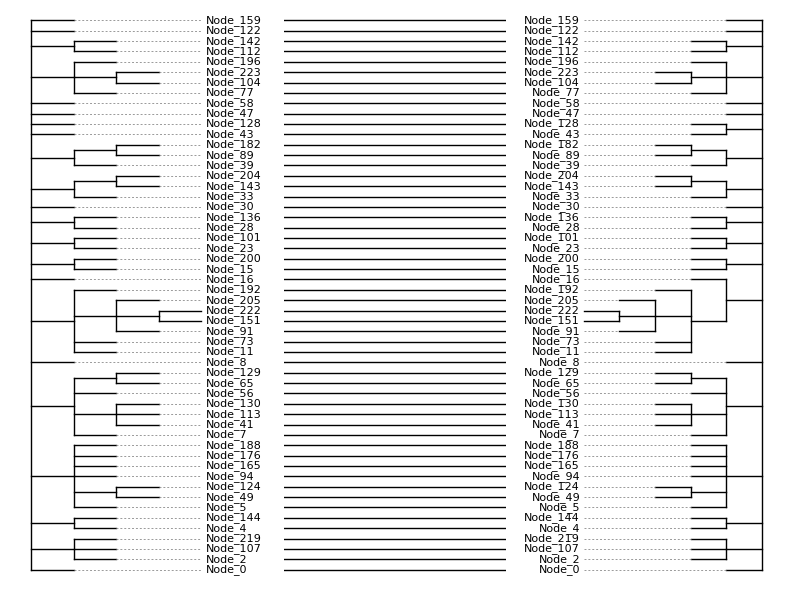

In [14]:
from cophylogeny.polytomy_tanglegram import run_polytomy_tanglegram

run_polytomy_tanglegram(newick_str, newick_bl1_path)